In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.stats import kurtosis
from scipy.fft import fft
from scipy.signal import welch

In [47]:
directories_ciss = ["C:\\Users\\germa\\Downloads\\data\\Worn_tool_no1_pattern1\\CISSRawData_LogFiles","C:\\Users\\germa\\Downloads\\data\\Worn_tool_no2_pattern2\\CISSRawData_LogFiles","C:\\Users\\germa\\Downloads\\data\\Worn_tool_no3_pattern3\\CISSRawData_LogFiles",
                    "C:\\Users\\germa\\Downloads\\data\\Good_tool_no1_pattern4\\CISSRawData_LogFiles","C:\\Users\\germa\\Downloads\\data\\Good_tool_no2_pattern5\\CISSRawData_LogFiles"]
directories_registry = ["C:\\Users\\germa\\Downloads\\data\\Worn_tool_no1_pattern1", "C:\\Users\\germa\\Downloads\\data\\Worn_tool_no2_pattern2", "C:\\Users\\germa\\Downloads\\data\\Worn_tool_no3_pattern3", 
                        "C:\\Users\\germa\\Downloads\\data\\Good_tool_no1_pattern4", "C:\\Users\\germa\\Downloads\\data\\Good_tool_no2_pattern5"]

In [48]:
def get_ciss_raw(directory):
    dataframes = []
    for filename in os.listdir(directory):
        if filename.endswith(".csv"):
            file_path = os.path.join(directory, filename)
            df = pd.read_csv(file_path, skiprows=8, encoding='Windows-1252')
            df = df.iloc[:-1]  # Remove the last row
            df.rename(columns={"Unix TimeStamp (ms)": "TimeStamp", "Data / x_axis": "x_axis"}, inplace=True)
            df["TimeStamp"] = pd.to_numeric(df["TimeStamp"]).astype(float)
            df.drop(columns=["Measurement Type"], inplace=True)
            if "Worn" in directory:
                df["Label"] = 1
            elif "Good" in directory:
                df["Label"] = 0
             # Initialize good tool with the value 0
            dataframes.append(df)
    df = pd.concat(dataframes)
    return df

In [49]:
def get_registry_record(directory):
    dataframes = []
    for filename in os.listdir(directory):
        if filename.endswith(".csv"):
            file_path = os.path.join(directory, filename)
            df = pd.read_csv(file_path)
            df.rename(columns={"Unnamed: 0": "TimeStamp"}, inplace=True)
            df["TimeStamp"] = df["TimeStamp"].astype(str).str.replace(".", "", regex=False).str[:13]
            df["TimeStamp"] = pd.to_numeric(df["TimeStamp"]).astype(float)
            df.drop(columns=["WinPCNCRunning", "CurrentJobProgress", "CurrentJobTimeMin", "CurrentJobTimeSec", "CurrentJobCommandNo", "CurrentSpdOvr", "State"], inplace=True)
            dataframes.append(df)
    df = pd.concat(dataframes)
    return df

In [50]:
dataframes_ciss = []
for directory in directories_ciss:
    dataframes_ciss.append(get_ciss_raw(directory))

In [51]:
dataframes_ciss

[         TimeStamp  x_axis  y_axis  z_axis  Label
 0     1.733408e+12    19.0  -993.0     0.0      1
 1     1.733408e+12    11.0  -991.0     1.0      1
 2     1.733408e+12    19.0  -995.0     0.0      1
 3     1.733408e+12    19.0  -993.0     3.0      1
 4     1.733408e+12    11.0  -993.0     0.0      1
 ...            ...     ...     ...     ...    ...
 6626  1.733410e+12    11.0  -991.0    -1.0      1
 6627  1.733410e+12    21.0  -995.0     0.0      1
 6628  1.733410e+12    11.0  -997.0    -3.0      1
 6629  1.733410e+12    15.0  -987.0     5.0      1
 6630  1.733410e+12    13.0  -985.0     7.0      1
 
 [2381631 rows x 5 columns],
           TimeStamp  x_axis  y_axis  z_axis  Label
 0      1.733410e+12     7.0  -991.0     9.0      1
 1      1.733410e+12    19.0  -995.0    -1.0      1
 2      1.733410e+12    29.0  -985.0     7.0      1
 3      1.733410e+12     9.0  -989.0     3.0      1
 4      1.733410e+12     1.0  -987.0     7.0      1
 ...             ...     ...     ...     ... 

In [52]:
dataframes_registry = []
for directory in directories_registry:
    dataframes_registry.append(get_registry_record(directory))

In [53]:
dataframe_ciss = pd.concat(dataframes_ciss)
dataframe_ciss = dataframe_ciss.sort_values("TimeStamp", ascending=True)
dataframe_registry = pd.concat(dataframes_registry)
dataframe_registry = dataframe_registry.sort_values("TimeStamp", ascending=True)

In [54]:
dataframe_all = pd.merge_asof(dataframe_ciss, dataframe_registry, on="TimeStamp", direction="nearest")

In [55]:
dataframe_all

,TimeStamp,x_axis,y_axis,z_axis,Label,Pos_X,Pos_Y,Pos_Z
0,1.733408e+12,19.0,-993.0,0.0,1,31975.0,231487.0,0.0
1,1.733408e+12,21.0,-989.0,0.0,1,31975.0,231487.0,0.0
2,1.733408e+12,11.0,-985.0,7.0,1,31975.0,231487.0,0.0
3,1.733408e+12,23.0,-989.0,-1.0,1,31975.0,231487.0,0.0
4,1.733408e+12,13.0,-993.0,1.0,1,31975.0,231487.0,0.0
...,...,...,...,...,...,...,...,...
12374310,1.733416e+12,19.0,-999.0,0.0,0,31975.0,231487.0,6062.0
12374311,1.733416e+12,15.0,-995.0,9.0,0,31975.0,231487.0,6062.0
12374312,1.733416e+12,15.0,-991.0,17.0,0,31975.0,231487.0,6062.0
12374313,1.733416e+12,33.0,-1001.0,7.0,0,31975.0,231487.0,6062.0


In [56]:
# Delete all the data in TimeStamp where the position of the milling tool was above the metal plate
peak_threshold = 0.975 * dataframe_all["Pos_Z"].max()
dataframe_all = dataframe_all[dataframe_all["Pos_Z"] >= peak_threshold]

C:\Users\germa\AppData\Local\Temp\ipykernel_4732\2250296532.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_all['TimeStamp'] = pd.to_datetime(dataframe_all['TimeStamp'], unit='ms')
C:\Users\germa\AppData\Local\Temp\ipykernel_4732\2250296532.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_all['Elapsed_Time'] = (dataframe_all['TimeStamp'] - dataframe_all['TimeStamp'].iloc[0]).dt.total_seconds()


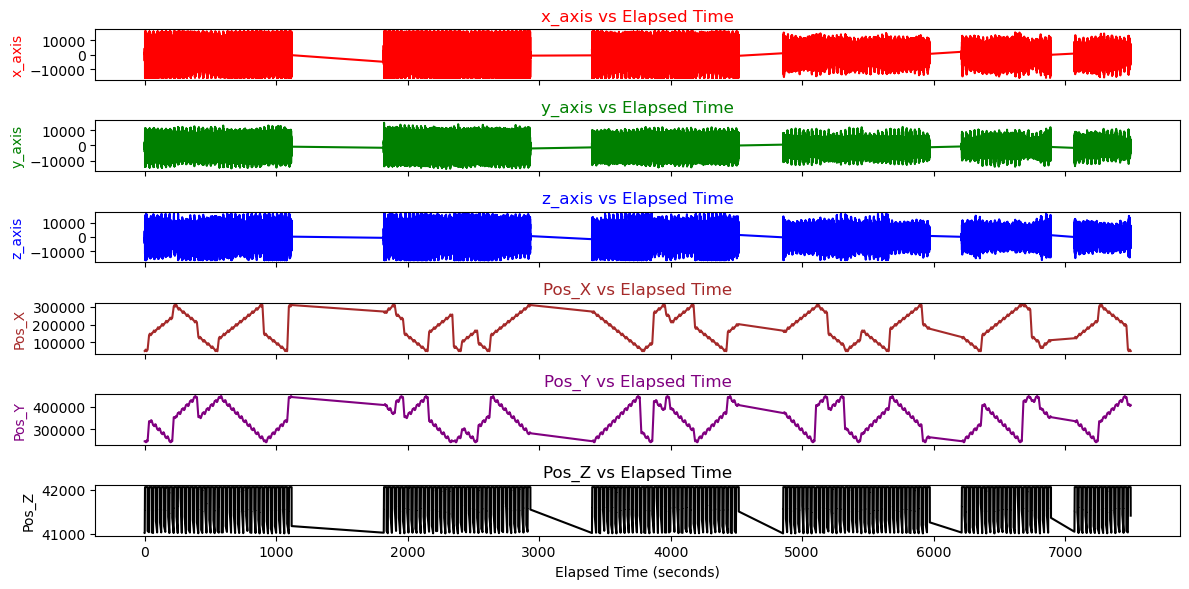

In [57]:
# Convert TimeStamp from numeric to datetime
dataframe_all['TimeStamp'] = pd.to_datetime(dataframe_all['TimeStamp'], unit='ms')

# List of columns to plot
columns_to_plot = ['x_axis', 'y_axis', 'z_axis','Pos_X','Pos_Y','Pos_Z']

# Calculate the elapsed time since the recording started
dataframe_all['Elapsed_Time'] = (dataframe_all['TimeStamp'] - dataframe_all['TimeStamp'].iloc[0]).dt.total_seconds()

# Plot the data with the elapsed time
fig, axes = plt.subplots(len(columns_to_plot), 1, figsize=(12, 6), sharex=True)
colors = ['red', 'green', 'blue', 'brown', 'purple', 'black']

# Plot each column
for ax, col, color in zip(axes, columns_to_plot, colors):
    ax.plot(dataframe_all['Elapsed_Time'], dataframe_all[col], label=col, color=color)
    ax.set_title(f'{col} vs Elapsed Time', color=color)  # Optional: Title color matches line
    ax.set_ylabel(col, color=color)  # Optional: Y-axis label matches color

# Set common x-axis label
plt.xlabel('Elapsed Time (seconds)')
plt.tight_layout()
plt.show()

In [58]:
dataframe_all

,TimeStamp,x_axis,y_axis,z_axis,Label,Pos_X,Pos_Y,Pos_Z,Elapsed_Time
90400,2024-12-05 14:21:00.801,1335.0,-2201.0,-2197.0,1,50575.0,244987.0,41021.0,0.00
90401,2024-12-05 14:21:00.801,1059.0,-1481.0,671.0,1,50575.0,244987.0,41021.0,0.00
90402,2024-12-05 14:21:00.801,-1118.0,-1885.0,650.0,1,50575.0,244987.0,41021.0,0.00
90403,2024-12-05 14:21:00.801,-220.0,-1270.0,212.0,1,50575.0,244987.0,41021.0,0.00
90404,2024-12-05 14:21:00.801,798.0,-534.0,-601.0,1,50575.0,244987.0,41021.0,0.00
...,...,...,...,...,...,...,...,...,...
12346775,2024-12-05 16:25:59.361,-111.0,-905.0,-1895.0,0,50575.0,406987.0,41415.0,7498.56
12346776,2024-12-05 16:25:59.361,1114.0,-1214.0,1602.0,0,50575.0,406987.0,41415.0,7498.56
12346777,2024-12-05 16:25:59.361,-837.0,-1665.0,-1036.0,0,50575.0,406987.0,41415.0,7498.56
12346778,2024-12-05 16:25:59.361,52.0,-1624.0,790.0,0,50575.0,406987.0,41415.0,7498.56


In [59]:
dataframe_all.drop(columns=["Pos_X", "Pos_Y", "Pos_Z"], inplace=True)

C:\Users\germa\AppData\Local\Temp\ipykernel_4732\4133081645.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_all.drop(columns=["Pos_X", "Pos_Y", "Pos_Z"], inplace=True)


Mean: -148.1716
Median: -130.0000
Variance: 36968284.3165
Kurtosis: -0.0314
Peak Frequency: 0.0000


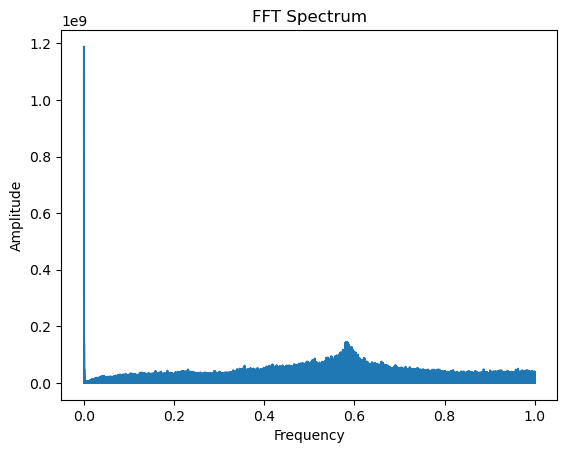

Dominant Frequency from PSD: 0.2930


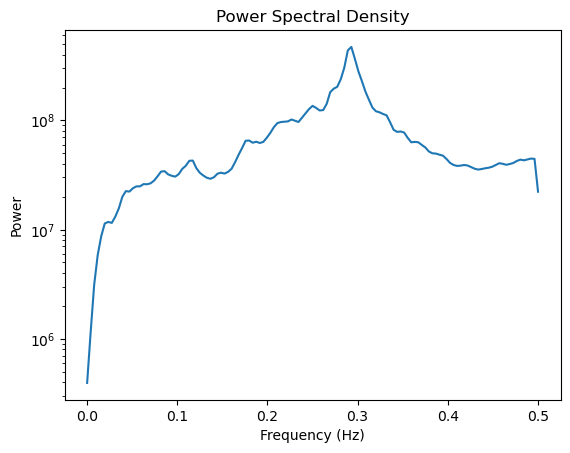

Root Mean Square (RMS): 6081.9601
Zero-Crossing Rate: 0.5500


In [60]:
# Statistical metrics
mean = np.mean(dataframe_all['x_axis'])
median = np.median(dataframe_all['x_axis'])
variance = np.var(dataframe_all['x_axis'])
kurt = kurtosis(dataframe_all['x_axis'])


print(f"Mean: {mean:.4f}")
print(f"Median: {median:.4f}")
print(f"Variance: {variance:.4f}")
print(f"Kurtosis: {kurt:.4f}")

# FFT on signal
signal = dataframe_all['x_axis'].to_numpy()  # Convert to NumPy array
N = len(signal)
fft_values = np.abs(fft(signal))[:N // 2]  # Take positive frequencies
frequencies = np.linspace(0, 1, N // 2)  # Frequency range

# Find the peak frequency
peak_freq = frequencies[np.argmax(fft_values)]

print(f"Peak Frequency: {peak_freq:.4f}")

# Plot FFT spectrum
plt.plot(frequencies, fft_values)
plt.title("FFT Spectrum")
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.show()

# Compute Power Spectral Density
frequencies, psd = welch(signal, fs=1.0, nperseg=256)  # fs = Sampling frequency

# Find dominant frequency
dominant_freq = frequencies[np.argmax(psd)]

print(f"Dominant Frequency from PSD: {dominant_freq:.4f}")

# Plot PSD
plt.semilogy(frequencies, psd)
plt.title("Power Spectral Density")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.show()

# RMS calculation
rms = np.sqrt(np.mean(signal**2))

print(f"Root Mean Square (RMS): {rms:.4f}")

# Zero-crossing rate
zero_crossings = np.where(np.diff(np.sign(signal)))[0]
zcr = len(zero_crossings) / len(signal)

print(f"Zero-Crossing Rate: {zcr:.4f}")

Mean: -985.6267
Median: -1007.0000
Variance: 10163974.8567
Kurtosis: 1.0609
Peak Frequency: 0.0000


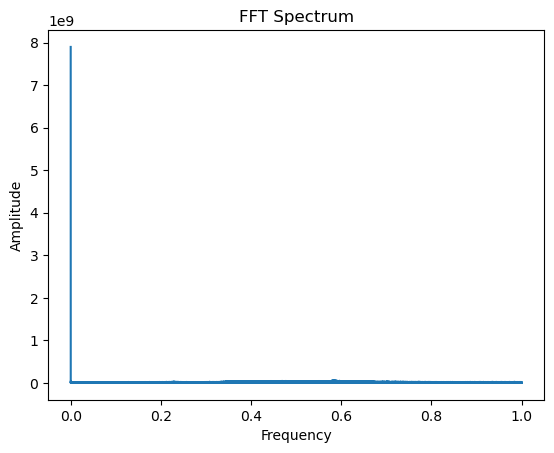

Dominant Frequency from PSD: 0.2930


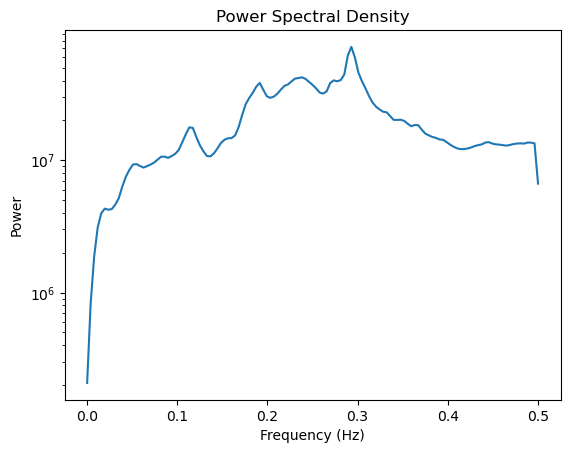

Root Mean Square (RMS): 3336.9799
Zero-Crossing Rate: 0.4394


In [61]:
# Statistical metrics
mean = np.mean(dataframe_all['y_axis'])
median = np.median(dataframe_all['y_axis'])
variance = np.var(dataframe_all['y_axis'])
kurt = kurtosis(dataframe_all['y_axis'])


print(f"Mean: {mean:.4f}")
print(f"Median: {median:.4f}")
print(f"Variance: {variance:.4f}")
print(f"Kurtosis: {kurt:.4f}")

# FFT on signal
signal = dataframe_all['y_axis'].to_numpy()  # Convert to NumPy array
N = len(signal)
fft_values = np.abs(fft(signal))[:N // 2]  # Take positive frequencies
frequencies = np.linspace(0, 1, N // 2)  # Frequency range

# Find the peak frequency
peak_freq = frequencies[np.argmax(fft_values)]

print(f"Peak Frequency: {peak_freq:.4f}")

# Plot FFT spectrum
plt.plot(frequencies, fft_values)
plt.title("FFT Spectrum")
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.show()

# Compute Power Spectral Density
frequencies, psd = welch(signal, fs=1.0, nperseg=256)  # fs = Sampling frequency

# Find dominant frequency
dominant_freq = frequencies[np.argmax(psd)]

print(f"Dominant Frequency from PSD: {dominant_freq:.4f}")

# Plot PSD
plt.semilogy(frequencies, psd)
plt.title("Power Spectral Density")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.show()

# RMS calculation
rms = np.sqrt(np.mean(signal**2))

print(f"Root Mean Square (RMS): {rms:.4f}")

# Zero-crossing rate
zero_crossings = np.where(np.diff(np.sign(signal)))[0]
zcr = len(zero_crossings) / len(signal)

print(f"Zero-Crossing Rate: {zcr:.4f}")

Mean: 2.3484
Median: 85.0000
Variance: 23291613.3925
Kurtosis: 0.4640
Peak Frequency: 0.5797


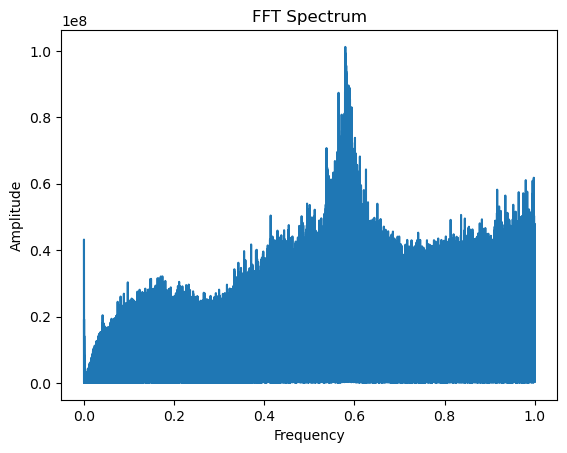

Dominant Frequency from PSD: 0.2930


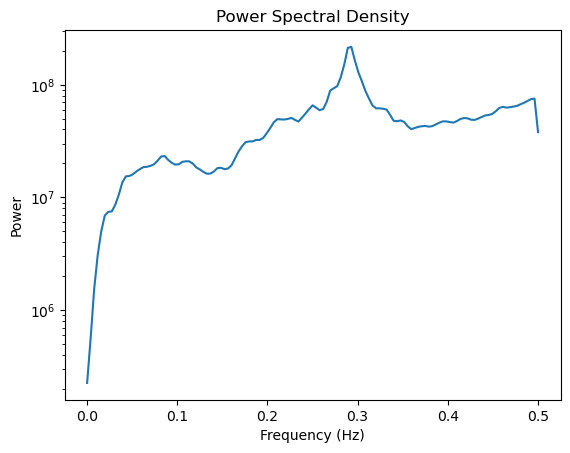

Root Mean Square (RMS): 4826.1391
Zero-Crossing Rate: 0.6050


In [62]:
# Statistical metrics
mean = np.mean(dataframe_all['z_axis'])
median = np.median(dataframe_all['z_axis'])
variance = np.var(dataframe_all['z_axis'])
kurt = kurtosis(dataframe_all['z_axis'])


print(f"Mean: {mean:.4f}")
print(f"Median: {median:.4f}")
print(f"Variance: {variance:.4f}")
print(f"Kurtosis: {kurt:.4f}")

# FFT on signal
signal = dataframe_all['z_axis'].to_numpy()  # Convert to NumPy array
N = len(signal)
fft_values = np.abs(fft(signal))[:N // 2]  # Take positive frequencies
frequencies = np.linspace(0, 1, N // 2)  # Frequency range

# Find the peak frequency
peak_freq = frequencies[np.argmax(fft_values)]

print(f"Peak Frequency: {peak_freq:.4f}")

# Plot FFT spectrum
plt.plot(frequencies, fft_values)
plt.title("FFT Spectrum")
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.show()

# Compute Power Spectral Density
frequencies, psd = welch(signal, fs=1.0, nperseg=256)  # fs = Sampling frequency

# Find dominant frequency
dominant_freq = frequencies[np.argmax(psd)]

print(f"Dominant Frequency from PSD: {dominant_freq:.4f}")

# Plot PSD
plt.semilogy(frequencies, psd)
plt.title("Power Spectral Density")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.show()

# RMS calculation
rms = np.sqrt(np.mean(signal**2))

print(f"Root Mean Square (RMS): {rms:.4f}")

# Zero-crossing rate
zero_crossings = np.where(np.diff(np.sign(signal)))[0]
zcr = len(zero_crossings) / len(signal)

print(f"Zero-Crossing Rate: {zcr:.4f}")

In [64]:
# Parameters
num_windows = 18000  # Number of desired windows
window_size = len(dataframe_all) // num_windows  # Calculate the window size dynamically
step_size = window_size  # Ensure no overlap between windows

# Create windows
windows = []
for i in range(0, len(dataframe_all), step_size):
    # Check if there's enough data left for a full window
    if i + window_size > len(dataframe_all):
        break
    
    # Extract the window data
    window_data = dataframe_all.iloc[i:i + window_size]
    
    # Calculate features
    features = {
        'x_mean': window_data['x_axis'].mean(),
        'x_std': window_data['x_axis'].std(),
        'x_sum': window_data['x_axis'].sum(),
        'x_median': window_data['x_axis'].median(),
        'y_mean': window_data['y_axis'].mean(),
        'y_std': window_data['y_axis'].std(),
        'y_sum': window_data['y_axis'].sum(),
        'y_median': window_data['y_axis'].median(),
        'z_mean': window_data['z_axis'].mean(),
        'z_std': window_data['z_axis'].std(),
        'z_sum': window_data['z_axis'].sum(),
        'z_median': window_data['z_axis'].median(),
        't_mean': window_data['Elapsed_Time'].mean(),
        't_std': window_data['Elapsed_Time'].std(),
        't_sum': window_data['Elapsed_Time'].sum(),
        't_median': window_data['Elapsed_Time'].median()
        # Add more features as needed
    }
    
    # Assign label based on majority
    label = window_data['Label'].mode()[0]
    features['Label'] = label
     
    windows.append(features)

# Convert to DataFrame
windowed_data = pd.DataFrame(windows)

In [65]:
windowed_data

,x_mean,x_std,x_sum,x_median,y_mean,y_std,y_sum,y_median,z_mean,z_std,z_sum,z_median,t_mean,t_std,t_sum,t_median,Label
0,2.797753,1714.420730,1245.0,62.0,-1007.883146,1180.965029,-448508.0,-1106.0,-8.098876,1387.944095,-3604.0,27.0,0.109045,0.063545,48.525,0.108,1
1,-3.191011,1777.761784,-1420.0,-23.0,-985.062921,1148.892403,-438353.0,-1011.0,15.384270,1375.068519,6846.0,95.0,0.329998,0.063237,146.849,0.328,1
2,-3.815730,1850.650938,-1698.0,105.0,-996.658427,1231.264912,-443513.0,-1071.0,4.164045,1393.358803,1853.0,64.0,0.546524,0.062419,243.203,0.549,1
3,-22.644944,1743.957604,-10077.0,21.0,-1001.017978,1196.155499,-445453.0,-1087.0,3.584270,1419.261094,1595.0,142.0,0.767537,0.064790,341.554,0.770,1
4,4.274157,1647.763377,1902.0,107.0,-1002.067416,1360.425768,-445920.0,-1056.0,-5.496629,1357.289538,-2446.0,70.0,0.987674,0.063358,439.515,0.991,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18004,7.876404,759.115960,3505.0,39.0,-992.489888,704.987306,-441658.0,-1128.0,11.161798,869.312756,4967.0,13.0,7497.421631,0.063747,3336352.626,7497.425,0
18005,4.267416,743.857763,1899.0,40.0,-1004.462921,708.631270,-446986.0,-1108.0,4.202247,883.445492,1870.0,23.0,7497.640402,0.063141,3336449.979,7497.643,0
18006,-6.669663,710.177446,-2968.0,37.0,-988.862921,709.051566,-440044.0,-1022.0,4.206742,865.023956,1872.0,-17.0,7497.861760,0.065115,3336548.483,7497.867,0
18007,2.746067,682.318395,1222.0,42.0,-996.570787,698.921114,-443474.0,-1085.0,4.687640,879.300026,2086.0,-19.0,7498.080025,0.061775,3336645.611,7498.072,0


In [68]:
windowed_data.to_csv("RF_windowed.csv")